In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [117]:
df_original = pd.read_excel('./datasets/dataset.xlsx')
df_original.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

In [118]:
df = df_original.copy()
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [119]:
df.shape

(5644, 111)

**Formatage des colonnes**

In [120]:
def format_col_name(col_name_ : str) -> str:
    """
    Formats a column name by converting it to lowercase, replacing spaces with underscores,
    and trimming unnecessary whitespace. If the input contains a parenthesis, the function
    only processes the substring before the parenthesis.

    :param col_name_: The name of the column to be formatted.
    :return: The formatted column name with spaces replaced by underscores and converted
        to lowercase.
    """
    if col_name_.find('(') == -1:
        return col_name_.strip(' ').replace(' ', '_').lower()
    return col_name_[ :col_name_.find('(')].strip(' ').replace(' ', '_').lower()

In [121]:
df.rename(columns={col : format_col_name(col) for col in df.columns}, inplace=True)

In [122]:
# Création des groupes de variables
missing_columns_a = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 76
missing_columns_b = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 89

respiratory_pathogens = list(df.columns[missing_columns_a])
blood_cells = list(df.columns[missing_columns_b])
patient_age_quantile = ['patient_age_quantile']
target = ['sars-cov-2_exam_result']
care_type = ['patient_addmited_to_regular_ward', 'patient_addmited_to_semi-intensive_unit', 'patient_addmited_to_intensive_care_unit']

df = df[respiratory_pathogens + blood_cells + patient_age_quantile + care_type + target]

In [123]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import  make_pipeline

In [124]:
def encodage(df_):
    encoder_dict = {
        'detected' : 1,
        'not_detected' : 0,
        'positive' : 1,
        'negative' : 0
    }
    for col in df_.select_dtypes(include='str').columns:
        df_[col] = df_[col].map(encoder_dict)

    return df_

In [125]:
def assign_classes(df_):
    if df_['patient_addmited_to_regular_ward']==1:
        return 0
    elif df_['patient_addmited_to_semi-intensive_unit']==1:
        return 1
    elif df_['patient_addmited_to_intensive_care_unit']==1:
        return 2
    return np.nan

def feature_engineering(df_):
    df_['positif_to_pathogenes'] = df_[respiratory_pathogens].sum(axis=1, skipna=True) >= 1
    df_['care_type'] = df_.apply(assign_classes, axis=1)

    df_ = df_.drop(columns=respiratory_pathogens)
    df_ = df_.drop(columns=care_type)
    return df_

In [126]:
def imputation(df_):
    df_ = df_.dropna(axis=0)
    return df_

In [127]:
def preprocessing(df_):
    df_ = encodage(df_)
    df_ = feature_engineering(df_)
    df_ = imputation(df_)

    X_ = df_.drop(columns='sars-cov-2_exam_result')
    y_ = df_['sars-cov-2_exam_result']

    print(f"X shape ==> {X_.shape}")
    print(f"y shape ==> {y_.shape}")
    return X_, y_

In [128]:
from sklearn.model_selection import train_test_split, learning_curve

trainset, testset = train_test_split(df, test_size=0.2, random_state=321)

In [129]:
X_train, y_train = preprocessing(trainset)

X shape ==> (100, 17)
y shape ==> (100,)


In [130]:
X_test, y_test = preprocessing(testset)

X shape ==> (28, 17)
y shape ==> (28,)


In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [132]:
model = make_pipeline(SelectKBest(score_func=f_classif, k=10), RandomForestClassifier(random_state=321))

In [133]:
def evaluation():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(confusion_matrix(y_pred=y_pred, y_true=y_test))
    print("Accuracy : ", accuracy_score(y_pred=y_pred, y_true=y_test))
    print("f1 score : ", f1_score(y_pred=y_pred, y_true=y_test))
    print(classification_report(y_pred=y_pred, y_true=y_test))

In [134]:
evaluation()

[[15  0]
 [ 4  9]]
Accuracy :  0.8571428571428571
f1 score :  0.8181818181818182
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.69      0.82        13

    accuracy                           0.86        28
   macro avg       0.89      0.85      0.85        28
weighted avg       0.89      0.86      0.85        28



In [135]:
N, train_score, val_score = learning_curve(estimator=model, X=X_train, y=y_train, cv=5, train_sizes=np.linspace(0.2, 1.0, 10), random_state=321, scoring='f1')

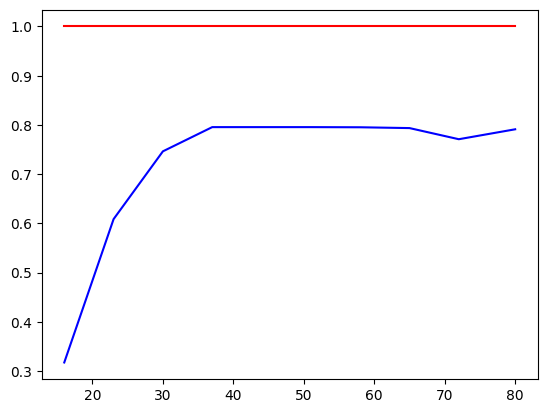

In [136]:
plt.figure()
plt.plot(N, train_score.mean(axis=1), color="red")
plt.plot(N, val_score.mean(axis=1), color="blue")
plt.show()

In [137]:
# Extraction des noms des colonnes sélectionnées par SelectKBest
# Les noms originaux sont dans X_train.columns
selected_features = X_train.columns[model.named_steps['selectkbest'].get_support()]

# Extraction des importances du RandomForest
importances = model.named_steps['randomforestclassifier'].feature_importances_

# Création d'un DataFrame pour une lecture facile
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance (%)': importances * 100
}).sort_values(by='Importance (%)', ascending=False)

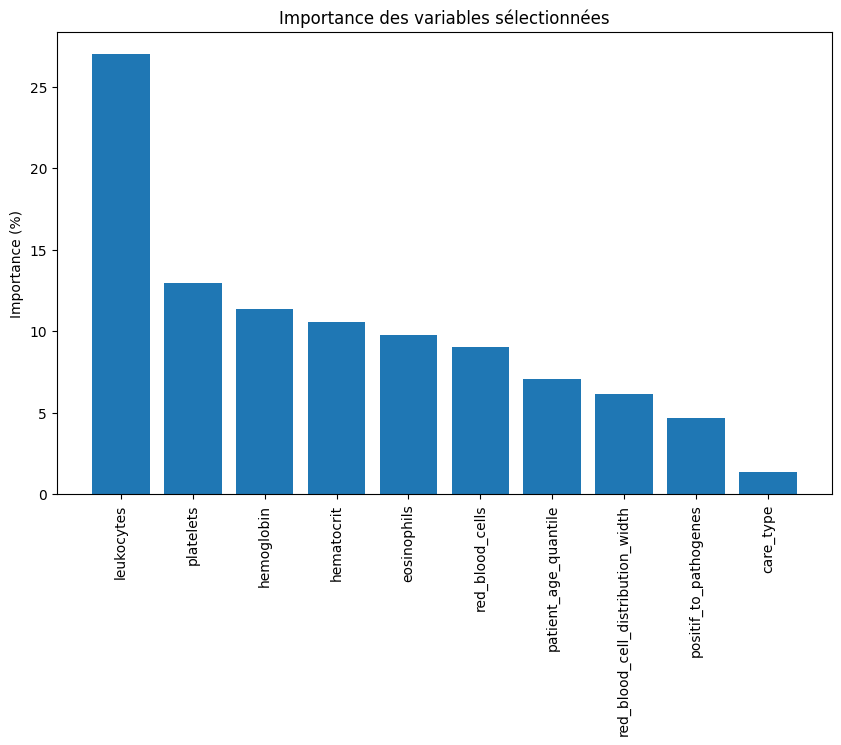

In [138]:
plt.figure(figsize=(10, 6))
plt.bar(x=feature_importance_df['Feature'], height=feature_importance_df['Importance (%)'])
plt.xticks(rotation=90)
plt.ylabel('Importance (%)')
plt.title('Importance des variables sélectionnées')
plt.show()